# Christenson: Merge Titles and Lines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
src_id = "christenson"

# Import CHAP and LINE

In [3]:
CHAP = pd.read_csv("christenson-CHAP.csv").set_index('chap_num')
CHAP['n_lines'] = CHAP.xom_end_fixed - CHAP.xom_start_fixed + 1
LINE = pd.read_csv("christenson-LINE_LITERAL.csv").set_index(['line_num'])
len(LINE), len(CHAP)

(8726, 87)

# CHAP and LINE to CHAP_LINE

In [4]:
OHCO = ['chap_num','line_num']

CHAP_LINE = CHAP.reset_index().merge(LINE, right_on='line_num', left_on='xom_start_fixed', how='right')
CHAP_LINE.chap_num = CHAP_LINE.chap_num.ffill()
CHAP_LINE.chap_num = CHAP_LINE.chap_num.astype(int)
CHAP_LINE = CHAP_LINE.reset_index()
CHAP_LINE = CHAP_LINE.rename(columns={'index':'line_num'})
CHAP_LINE.line_num = CHAP_LINE.line_num + 1
CHAP_LINE = CHAP_LINE.set_index(OHCO)
CHAP_LINE.head()

chap_title  page_num  xom_start  xom_end  xom_start_fixed  \
chap_num line_num                                                             
1        1          Preamble      59.0        1.0     96.0              1.0   
         2               NaN       NaN        NaN      NaN              NaN   
         3               NaN       NaN        NaN      NaN              NaN   
         4               NaN       NaN        NaN      NaN              NaN   
         5               NaN       NaN        NaN      NaN              NaN   

                   xom_end_fixed  n_lines                       eng_str  \
chap_num line_num                                                         
1        1                  96.0     96.0   THIS ITS ROOT ANCIENT WORD,   
         2                   NaN      NaN         Here Quiché its name.   
         3                   NaN      NaN          HERE we shall write,   
         4                   NaN      NaN  We shall plant ancient word,   
         5                   NaN      NaN                 Its planting,   

                                        quc_str  line_marker  
chap_num line_num                                             
1        1                ARE' U XE' OJER TZIJ,          NaN  
         2                Waral K'iche' u b'i'.          NaN  
         3             WARAL xchiqatz'ib'aj wi,          NaN  
         4         Xchiqatikib'a' wi ojer tzij,          NaN  
         5                        U tikarib'al,          NaN

# CHAP_LINE to CHAP_LINE_SIMPLE

`CHAP_LINE_SIMPLE` has only `OHCO` and the language strings.

In [5]:
CHAP_LINE_SIMPLE = CHAP_LINE[['eng_str','quc_str']].copy()
CHAP_LINE_SIMPLE.quc_str = CHAP_LINE_SIMPLE.quc_str.astype(str)
CHAP_LINE_SIMPLE.eng_str = CHAP_LINE_SIMPLE.eng_str.astype(str)
CHAP_LINE_SIMPLE

eng_str  \
chap_num line_num                                                     
1        1                              THIS ITS ROOT ANCIENT WORD,   
         2                                    Here Quiché its name.   
         3                                     HERE we shall write,   
         4                             We shall plant ancient word,   
         5                                            Its planting,   
...                                                             ...   
87       8722            This because not now means of sight of it.   
         8723                    There is first anciently by lords.   
         8724                                             Lost now.   
         8725      But therefore this was completed now all Quiché,   
         8726                                   Sta. Cruz its name.   

                                                         quc_str  
chap_num line_num                                                 
1        1                                 ARE' U XE' OJER TZIJ,  
         2                                 Waral K'iche' u b'i'.  
         3                              WARAL xchiqatz'ib'aj wi,  
         4                          Xchiqatikib'a' wi ojer tzij,  
         5                                         U tikarib'al,  
...                                                          ...  
87       8722                  Ri' rumal maja b'i chi ilb'al re.  
         8723                      K'o nab'e ojer kumal ajawab'.  
         8724                                     Sachinaq chik.  
         8725      Xere k'u ri' mi xutzinik chi konojel K'iche',  
         8726                                  Sta. Cruz u b'i'.  

[8726 rows x 2 columns]

# Move grouped lines back to CHAP

In [6]:
CHAP['chap_eng_str'] = CHAP_LINE_SIMPLE.groupby('chap_num').eng_str.apply(lambda x: ' '.join(x))
CHAP['chap_quc_str'] = CHAP_LINE_SIMPLE.groupby('chap_num').quc_str.apply(lambda x: ' '.join(x))
CHAP.head()

,chap_title,page_num,xom_start,xom_end,xom_start_fixed,xom_end_fixed,n_lines,chap_eng_str,chap_quc_str
chap_num,,,,,,,,,
1,Preamble,59,1,96,1,96,96,"THIS ITS ROOT ANCIENT WORD, Here Quiché its na...","ARE' U XE' OJER TZIJ, Waral K'iche' u b'i'. WA..."
2,The Primordial World,67,97,154,97,154,58,THIS ITS ACCOUNT These things. Still be it sil...,"ARE' U TZIJOXIK Wa'e. K'a katz'ininoq, K'a kac..."
3,The Creation of the Earth,70,155,274,155,274,120,"THEN came therefore his word here, He arrived ...","TA xpe k'ut u tzij waral, Xul kuk' Ri Tepew, Q..."
4,The Creation of the Animals,74,275,339,275,339,65,THEN they conceived again Its animals mountain...,"TA xkino'jij chik U chikopil juyub', Chajal re..."
5,The Fall of the Animals,76,340,433,340,433,94,"THEN it was said to again therefore the deer, ...","TA xe'uchax chi k'ut ri kiej, Tz'ikin Rumal Tz..."


# CHAP_LINE_SIMPLE to TOKEN

In [7]:
# CHAP_LINE_SIMPLE.quc_str.apply(lambda x: re.findall(r"(?u)\b\w[\w']*\b", x)).apply(pd.Series).stack().to_frame('token_str')

In [8]:
TOKEN_QUC = CHAP_LINE_SIMPLE.quc_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN_QUC['term_str'] = TOKEN_QUC.token_str.str.lower().str.replace(r"[^\w']", "", regex=True)
TOKEN_QUC.index.names = ['chap_num','line_num','token_num']
TOKEN_QUC

token_str term_str
chap_num line_num token_num                   
1        1        0              ARE'     are'
                  1                 U        u
                  2               XE'      xe'
                  3              OJER     ojer
                  4             TZIJ,     tzij
...                               ...      ...
87       8725     7          K'iche',  k'iche'
         8726     0              Sta.      sta
                  1              Cruz     cruz
                  2                 u        u
                  3             b'i'.     b'i'

[29375 rows x 2 columns]

# TOKEN to VOCAB 

In [10]:
TOKEN = TOKEN_QUC

VOCAB = TOKEN.term_str.value_counts().to_frame('n').sort_index()
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB

,n,p,i,h
term_str,,,,
,2,0.000068,13.842301,0.000942
a,23,0.000783,10.318739,0.008079
a',12,0.000409,11.257339,0.004599
a'on,2,0.000068,13.842301,0.000942
ab'aj,31,0.001055,9.888105,0.010435
...,...,...,...,...
yoq'otajinaq,1,0.000034,14.842301,0.000505
yujuj,2,0.000068,13.842301,0.000942
yuq,1,0.000034,14.842301,0.000505


# TOKEN to CHUNK

In [17]:
n_chunks = 60

TOKEN['chunk_num'] = pd.cut(TOKEN.reset_index().index, n_chunks, labels=[x for x in range(n_chunks)])
TOKEN

token_str term_str chunk_num
chap_num line_num token_num                             
1        1        0              ARE'     are'         0
                  1                 U        u         0
                  2               XE'      xe'         0
                  3              OJER     ojer         0
                  4             TZIJ,     tzij         0
...                               ...      ...       ...
87       8725     7          K'iche',  k'iche'        59
         8726     0              Sta.      sta        59
                  1              Cruz     cruz        59
                  2                 u        u        59
                  3             b'i'.     b'i'        59

[29375 rows x 3 columns]

In [18]:
CHUNK = TOKEN.groupby('chunk_num', observed=True).term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK.head()

,chunk_str
chunk_num,
0,are' u xe' ojer tzij waral k'iche' u b'i' wara...
1,ta chawaxoq ta saqiro puch apachinaq tzuqul q'...
2,k'ajolom xe'uchax k'ut xa kixjalatajik rumal m...
3,che' xe'uchaxik e aj q'ij k'ate puch u qajik u...
4,ta nab'e qa patan chiwach ix ta na winaq wakam...


In [19]:
DOC = CHAP
CHUNK['doc_ids'] = DOC.join(TOKEN).join(CHUNK, on="chunk_num")\
    .reset_index()\
    .value_counts(['chunk_num', 'chap_num'])\
    .sort_index()\
    .reset_index().groupby('chunk_num', observed=True)\
    .chap_num.apply(lambda x: " ".join(map(str, x)))
CHUNK.head()

,chunk_str,doc_ids
chunk_num,,
0,are' u xe' ojer tzij waral k'iche' u b'i' wara...,1 2 3
1,ta chawaxoq ta saqiro puch apachinaq tzuqul q'...,3 4 5
2,k'ajolom xe'uchax k'ut xa kixjalatajik rumal m...,5 6 7
3,che' xe'uchaxik e aj q'ij k'ate puch u qajik u...,7 8
4,ta nab'e qa patan chiwach ix ta na winaq wakam...,8 9


# TOKEN to CTM

In [20]:
CTM = TOKEN.groupby(['chunk_num', 'term_str'], observed=True).term_str.count().unstack(fill_value=0)
CTM.head()

term_str,,a,a',a'on,ab'aj,ab'ajil,ab'anel,ab'ix,ab'ixik,ab'ixom,...,yojol,yolkwat,yoq',yoq'b'al,yoq'otaj,yoq'otajinaq,yujuj,yuq,yuyub',zuywa
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Choose SIGS

In [28]:
def get_dh():
    DP = CTM / CTM.sum()
    DI = np.log2(1/DP)
    DH = DP * DI
    return DH.sum()
VOCAB['dh'] = get_dh()

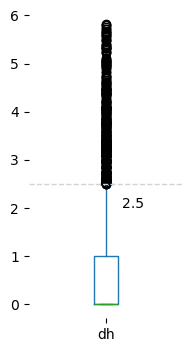

In [35]:
ax = VOCAB.dh.plot.box(figsize=(2,4))
vline = VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls='--', lw=1, c='lightgray')
ax.annotate(vline, xy=(1.1,2))
sns.despine(left=True, bottom=True)
plt.show()

In [30]:
SIGS = VOCAB[VOCAB.dh > 2.4].index
len(SIGS)

394

In [31]:
SIGS = VOCAB.sort_values('dh').tail(500).index

# CTM to TFIDF

In [32]:
TF = CTM[SIGS]
DF = TF[TF > 0].sum()
IDF = np.log((n_chunks+1)/(DF+1)+1)
TFIDF = TF * IDF
L2_norm = np.sqrt((TFIDF**2).sum(1))
TFIDF_L2 = TFIDF.div(L2_norm, axis=0)

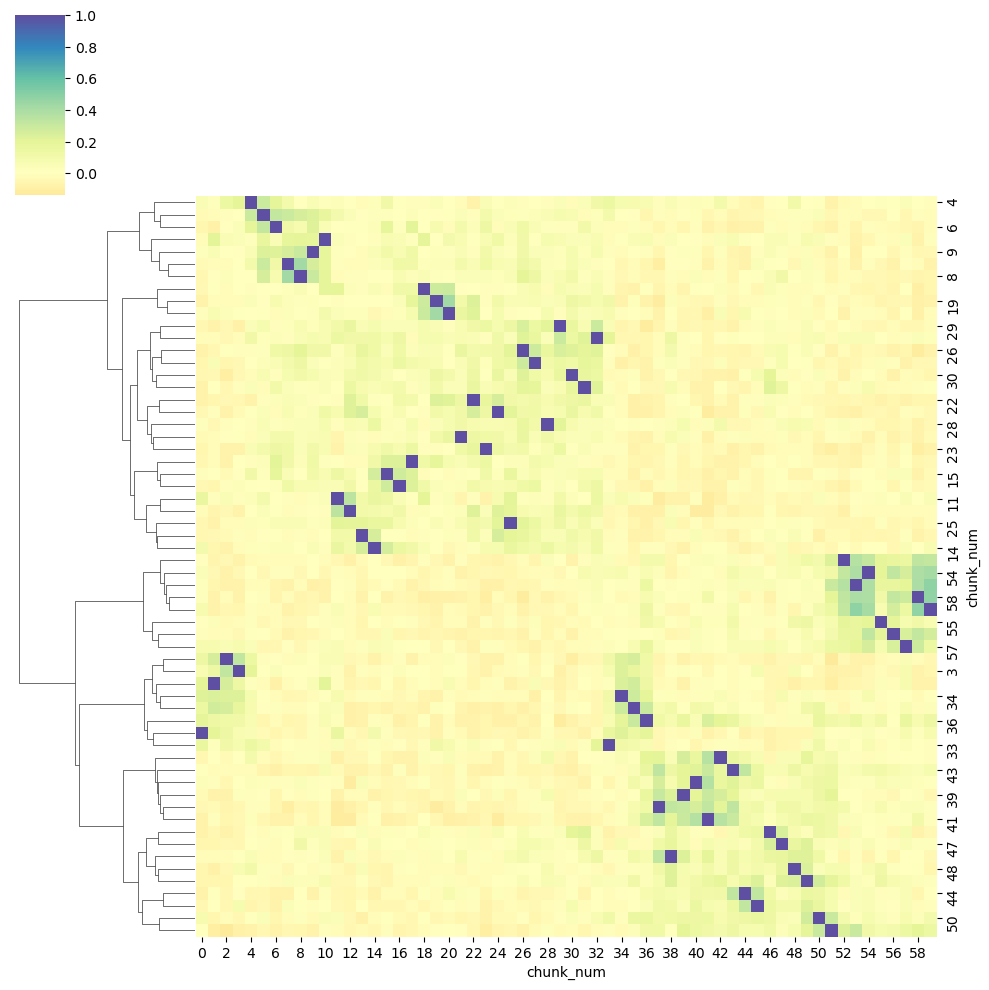

In [33]:
sns.clustermap(TFIDF_L2.T.corr(), cmap="Spectral", center=0, col_cluster=None, 
    metric='euclidean',
    method='ward')
plt.show()

# Save

In [34]:
CHAP_LINE_SIMPLE.to_csv("christenson-LINE_LITERAL-with-chaps.csv", index=True)
# CHAP.to_csv("christenson-CHAP-with-text.csv", index=True)
# TOKEN_QUC.to_csv("christenson-TOKEN_QUC.csv", index=True)
# VOCAB.to_csv("christenson-VOCAB.csv", index=True)
TOKEN.to_csv(f"{src_id}-TOKEN.csv", index=True)
VOCAB.to_csv(f"{src_id}-VOCAB.csv", index=True)
DOC.to_csv(f"{src_id}-DOC.csv", index=True)
CHUNK.to_csv(f"{src_id}-CHUNK-{n_chunks}.csv", index=True)
TFIDF_L2.to_csv(f"{src_id}-TFIDF-{n_chunks}.csv", index=True)